# ESS Battery Health - DAY1 EDA (Batch 1 + 2 + 3)

데이터셋 : Severson et al., *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)

**스토리 라인**
1. 수명은 셀마다 크게 다르고, 배치마다 분포도 다르다 (Q1)
2. 초기 용량만 보면 구분이 안 되고, 열화는 나중에 꺾인다 (Q2)
3. ΔQ(V)를 보면 초기에 이미 차이가 보인다 (Q3) + 몇 사이클이면 충분한가 (Extra)
4. 충전 속도는 영향이 있지만, 같은 조건에서도 편차가 크다 (Q4)
5. 피처 간 관계로 쓸 것과 버릴 것을 정한다 (Q5)
6. 모델 설계 전략

**실행 순서** : 0 → 1 (최초 1회만, 수 분 소요) → 2 이후

## 0. Setup

In [1]:
import os, re, gc, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 11, 'axes.unicode_minus': False})

# 경로 설정 (본인 환경에 맞게 수정)
DATA_DIR  = os.path.expanduser('~/Documents/data-science/skala-ds/90-MiniProject/data/data-30')
CACHE_DIR = './cache'
os.makedirs(CACHE_DIR, exist_ok=True)

BATCH_FILES = {
    'b1': '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    'b2': '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    'b3': '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}
BATCH_COLORS = {'b1': '#1f77b4', 'b2': '#ff7f0e', 'b3': '#2ca02c'}

EOL_AH     = 0.88   # 80% of nominal 1.1Ah
LABEL_TH   = 550    # Classification 기준 (수업 자료)
LONG_TH    = 1000   # Q1 장수명 기준
SHORT_TH   = 500    # Q1 단수명 기준

## 1. 데이터 추출 (최초 1회)

- `mat73.loadmat()`은 파일 **전체(I, V, t 등 모든 사이클 시계열)를 메모리에 올려서** 배치당 수 GB가 필요함
- 여기서는 `h5py`로 파일을 열어 **필요한 필드만 골라 읽음** → 메모리 사용이 수백 MB 수준으로 줄어듦
- 저장 항목 : 정책, cycle_life, summary, 지정 사이클의 `Qdlin` / `Tdlin` / `discharge_dQdV`, `Vdlin`
- 배치 하나씩 처리하고 pickle로 캐시 → 다음부터는 캐시만 읽음 (배치당 수십 MB)
- 공식 설명 : Batch1은 cycle 1 데이터가 구조체에 없음 → summary의 `cycle` 값으로 **사이클 번호와 인덱스를 매핑**

In [2]:
DATA_DIR = '/Users/hongdong-wan/Downloads/archive'


In [3]:
import h5py, time

KEEP_CYCLES = [2, 3, 4, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

def _arr(f, ref):
    return np.asarray(f[ref][()], dtype=float).ravel()

def _is_empty(f, ref):
    d = f[ref]
    return bool(d.attrs.get('MATLAB_empty', 0)) or d.size < 10

def _str(f, ref):
    return ''.join(chr(int(c)) for c in f[ref][()].ravel())

def extract_batch_h5(path, name):
    # h5py로 필요한 필드만 골라 읽기 (파일 전체를 메모리에 올리지 않음)
    out = []
    with h5py.File(path, 'r') as f:
        b = f['batch']
        n_cells = b['summary'].shape[0]
        for i in range(n_cells):
            try:
                s = f[b['summary'][i, 0]]
                summ = {k: np.asarray(s[k][()], dtype=float).ravel() for k in s.keys()}
                cyc = f[b['cycles'][i, 0]]
                n_cyc = cyc['Qdlin'].shape[0]
                # 사이클 번호 -> cycles 인덱스 매핑 (summary['cycle'] 기준, Batch1은 cycle 1이 비어 있음)
                cyc_no = summ.get('cycle', np.arange(1, n_cyc + 1))
                idx_of = {int(v): j for j, v in enumerate(cyc_no[:n_cyc])} if len(cyc_no) >= n_cyc \
                         else {j + 1: j for j in range(n_cyc)}
                curves = {}
                for c in KEEP_CYCLES:
                    j = idx_of.get(c)
                    if j is not None and not _is_empty(f, cyc['Qdlin'][j, 0]):
                        curves[c] = {'Qdlin': _arr(f, cyc['Qdlin'][j, 0]),
                                     'Tdlin': _arr(f, cyc['Tdlin'][j, 0]),
                                     'dQdV' : _arr(f, cyc['discharge_dQdV'][j, 0])}
                life = _arr(f, b['cycle_life'][i, 0])
                out.append({
                    'batch': name, 'cell_id': f'{name}c{i}',
                    'policy': _str(f, b['policy_readable'][i, 0]),
                    'cycle_life': float(life[0]) if life.size else np.nan,
                    'n_cycles': n_cyc,
                    'empty_idx': [j for j in range(min(3, n_cyc)) if _is_empty(f, cyc['Qdlin'][j, 0])],
                    'summary': summ, 'curves': curves,
                    'Vdlin': _arr(f, b['Vdlin'][i, 0]),
                })
            except Exception as e:
                print(f'  {name}c{i} 건너뜀 : {e}')
            if (i + 1) % 10 == 0:
                print(f'  {name}: {i + 1}/{n_cells} cells')
    gc.collect()
    return out

RUN_BATCHES = ['b1', 'b2', 'b3']   # 메모리가 부족하면 ['b1'] 처럼 하나씩 실행

for name in RUN_BATCHES:
    pkl = os.path.join(CACHE_DIR, f'{name}.pkl')
    if os.path.exists(pkl):
        print(f'{name}: 캐시 있음 -> skip'); continue
    t0 = time.time(); print(f'{name}: 추출 시작')
    data = extract_batch_h5(os.path.join(DATA_DIR, BATCH_FILES[name]), name)
    with open(pkl, 'wb') as f:
        pickle.dump(data, f)
    print(f'{name}: {len(data)} cells 저장 ({os.path.getsize(pkl)/1e6:.0f} MB, {time.time()-t0:.0f}s) '
          f'/ 비어있는 index 예시 = {data[0]["empty_idx"]}')
    del data; gc.collect()

b1: 캐시 있음 -> skip
b2: 캐시 있음 -> skip
b3: 캐시 있음 -> skip


## 2. 로드 & 데이터 품질 점검

보고서 INPUT 슬라이드의 "데이터 정리 과정" 근거가 되는 부분

In [4]:
cells = []
for name in BATCH_FILES:
    with open(os.path.join(CACHE_DIR, f'{name}.pkl'), 'rb') as f:
        cells += pickle.load(f)

meta = pd.DataFrame([{k: c[k] for k in ['batch', 'cell_id', 'policy', 'cycle_life', 'n_cycles']}
                     for c in cells])
meta['has_dQ'] = [(10 in c['curves']) and (100 in c['curves']) for c in cells]

print('배치별 셀 수 :'); print(meta['batch'].value_counts().sort_index(), '\n')
print('cycle_life NaN (EOL 미도달 등) :'); print(meta[meta['cycle_life'].isna()][['cell_id', 'policy', 'n_cycles']], '\n')
print('기록된 사이클 수 < cycle_life (다른 배치에서 실험이 이어졌을 가능성) :')
print(meta[meta['n_cycles'] < meta['cycle_life']][['cell_id', 'policy', 'n_cycles', 'cycle_life']], '\n')
print('ΔQ 계산 불가 셀 :'); print(meta[~meta['has_dQ']][['cell_id', 'n_cycles']])

배치별 셀 수 :
batch
b1    46
b2    47
b3    46
Name: count, dtype: int64 

cycle_life NaN (EOL 미도달 등) :
    cell_id                       policy  n_cycles
68    b2c22       VarCharge-2C-100cycles       920
69    b2c23       VarCharge-4C-100cycles      1152
81    b2c35       VarCharge-6C-100cycles       423
82    b2c36       VarCharge-8C-100cycles       280
83    b2c37     3.6C(80%)-3.6C(SLOWCYCLE       101
84    b2c38     4.8C(80%)-4.8C(SLOWCYCLE       101
85    b2c39        3.6C(9%)-5C(SLOWCYCLE       434
86    b2c40       5.2C(58%)-4C(SLOWCYCLE       459
116   b3c23  4.8C(80%)-4.8C-newstructure      2189
125   b3c32  4.8C(80%)-4.8C-newstructure      2237 

기록된 사이클 수 < cycle_life (다른 배치에서 실험이 이어졌을 가능성) :
    cell_id                       policy  n_cycles  cycle_life
0      b1c0               3.6C(80%)-3.6C      1189      1190.0
1      b1c1               3.6C(80%)-3.6C      1178      1179.0
2      b1c2               3.6C(80%)-3.6C      1176      1177.0
3      b1c3                   4C(80%)

### 배치별 실험 조건 차이 (공식 데이터 설명 기준) — 배치 비교 해석의 근거

| 항목 | Batch1 (2017-05-12) | Batch3 (2018-04-12) | 해석 포인트 |
|---|---|---|---|
| 충전 정책 | 1·2단계, 충전시간 8~13.3분 | 2단계, **충전시간 10분 고정** | b3에서는 충전시간/avg C-rate가 거의 상수 → 해당 피처의 설명력이 배치마다 다를 수 있음 |
| 정책당 셀 수 | 대부분 2개 | 3~8개 | 같은 정책 내 편차는 b3에서 더 신뢰도 높게 측정 가능 |
| CV 차단 전류 | C/50 | C/20 | 용량 측정 조건 차이 |
| IR 펄스 폭 | 30 ms | 33 ms | **IR 절대값은 배치 간 직접 비교 주의** |
| 기타 | 컴퓨터 재부팅 2회(시간 공백), 챔버 온도 불안정, 채널 15·16 열전대 바뀜 | OCV 오류로 일시 정지 셀 존재 | 온도 피처 신뢰도 한계 |

- 공통 : LFP/흑연 A123 셀, 공칭 1.1Ah, 30°C 챔버, 4C 방전, EOL = 0.88Ah
- 온도 측정은 열전대 접촉 상태에 따라 신뢰도가 떨어질 수 있음 (공식 설명) → 온도 피처는 보조로 사용
- **확인 필요** : 공식 로딩 코드의 Batch2는 `2017-06-30` 파일인데, 과제의 Batch2는 `2018-02-20` 파일. 공식 설명에서 `2018-02-20`은 Figure 4용 데이터로 소개됨 → 아래 점검 결과(셀 수, 수명 분포, 정책)를 보고 강사님께 확인 권장

In [5]:
# 공식 로딩 코드(rdbraatz/data-driven-prediction...의 Load Data) 기준 제외 셀
EXCLUDE_REASON = {
    **{c: 'EOL(80%) 도달 전 테스트 종료' for c in ['b1c8', 'b1c10', 'b1c12', 'b1c13', 'b1c22']},
    **{c: '2017-06-30 배치로 이어진 셀 (이어진 데이터가 우리 파일에 없음 -> 수명 불완전)' for c in ['b1c0', 'b1c1', 'b1c2', 'b1c3', 'b1c4']},
    **{c: '노이즈 채널' for c in ['b3c2', 'b3c23', 'b3c32', 'b3c37', 'b3c42', 'b3c43']},
}
EXCLUDE = list(EXCLUDE_REASON)   # b2(2018-02-20)는 공식 코드 대상이 아니므로 위 점검 결과로 추가 판단
print(pd.Series(EXCLUDE_REASON).to_frame('reason'))

valid = meta['cycle_life'].notna() & meta['has_dQ'] & ~meta['cell_id'].isin(EXCLUDE) \
        & (meta['n_cycles'] >= meta['cycle_life'].fillna(0) * 0.95)
meta = meta[valid].reset_index(drop=True)
cells = [c for c in cells if c['cell_id'] in set(meta['cell_id'])]
cell_map = {c['cell_id']: c for c in cells}
meta['log_life'] = np.log10(meta['cycle_life'])
print(f'분석 대상 : {len(meta)} cells'); print(meta['batch'].value_counts().sort_index())

                                                  reason
b1c8                                EOL(80%) 도달 전 테스트 종료
b1c10                               EOL(80%) 도달 전 테스트 종료
b1c12                               EOL(80%) 도달 전 테스트 종료
b1c13                               EOL(80%) 도달 전 테스트 종료
b1c22                               EOL(80%) 도달 전 테스트 종료
b1c0   2017-06-30 배치로 이어진 셀 (이어진 데이터가 우리 파일에 없음 -> 수명...
b1c1   2017-06-30 배치로 이어진 셀 (이어진 데이터가 우리 파일에 없음 -> 수명...
b1c2   2017-06-30 배치로 이어진 셀 (이어진 데이터가 우리 파일에 없음 -> 수명...
b1c3   2017-06-30 배치로 이어진 셀 (이어진 데이터가 우리 파일에 없음 -> 수명...
b1c4   2017-06-30 배치로 이어진 셀 (이어진 데이터가 우리 파일에 없음 -> 수명...
b3c2                                              노이즈 채널
b3c23                                             노이즈 채널
b3c32                                             노이즈 채널
b3c37                                             노이즈 채널
b3c42                                             노이즈 채널
b3c43                                             노이즈 채널
분석 대상 : 115 cells
batch
b1    3

In [6]:
# summary -> long DataFrame (정제 포함)
rows = []
for c in cells:
    s = c['summary']
    n = len(s['QDischarge'])
    cyc_no = s['cycle'] if 'cycle' in s and len(s['cycle']) == n else np.arange(n)
    d = pd.DataFrame({
        'cell_id': c['cell_id'], 'batch': c['batch'], 'cycle': cyc_no,
        'QD': s['QDischarge'], 'QC': s.get('QCharge', np.full(n, np.nan)),
        'IR': s.get('IR', np.full(n, np.nan)), 'Tmax': s.get('Tmax', np.full(n, np.nan)),
        'Tavg': s.get('Tavg', np.full(n, np.nan)), 'Tmin': s.get('Tmin', np.full(n, np.nan)),
        'chargetime': s.get('chargetime', np.full(n, np.nan)),
    })
    rows.append(d)
summ = pd.concat(rows, ignore_index=True)
n0 = len(summ)

# 정제 규칙 (보고서에 그대로 기록)
summ = summ[summ['QD'] > 0]                                   # 1) 0값 행 (첫 사이클 등)
summ = summ[summ['QD'].between(0.8, 1.3)]                      # 2) 용량 스파이크
summ.loc[~summ['chargetime'].between(5, 60), 'chargetime'] = np.nan   # 3) 충전시간 이상값
summ.loc[summ['IR'] <= 0, 'IR'] = np.nan
summ = summ.merge(meta[['cell_id', 'cycle_life']], on='cell_id')
print(f'정제 : {n0:,} -> {len(summ):,} rows ({(n0-len(summ))/n0*100:.2f}% 제거)')

정제 : 92,621 -> 92,584 rows (0.04% 제거)


## Q1. Cycle Life 분포는 어떻게 생겼는가?

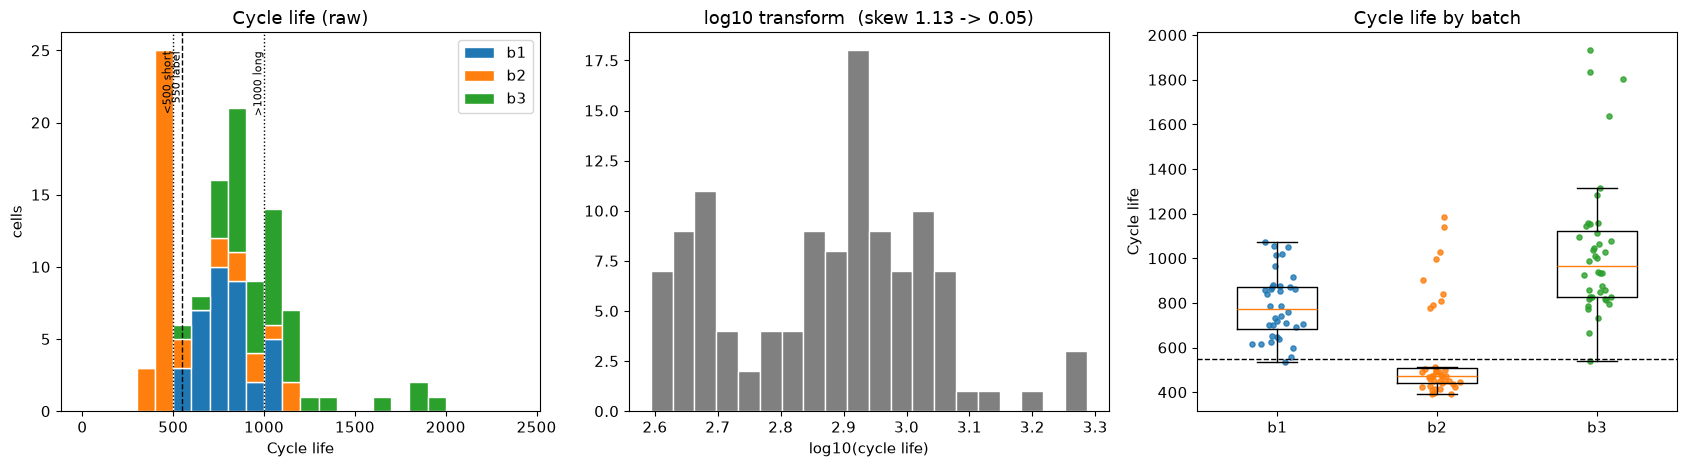

,n,mean,median,std,min,max,long(>1000)%,short(<500)%,label=0(<550) n
batch,,,,,,,,,
b1,36.0,788.4,772.5,148.7,534.0,1074.0,13.9,0.0,1.0
b2,39.0,565.7,472.0,222.2,392.0,1186.0,7.7,71.8,30.0
b3,40.0,1032.0,964.5,308.6,541.0,1935.0,47.5,0.0,1.0
all,115.0,797.6,796.0,305.8,392.0,1935.0,23.5,24.3,32.0


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
bins = np.arange(0, 2500, 100)
groups = [meta.loc[meta['batch'] == b, 'cycle_life'] for b in BATCH_FILES]
ax[0].hist(groups, bins=bins, stacked=True, label=list(BATCH_FILES),
           color=list(BATCH_COLORS.values()), edgecolor='white')
for x, ls, lab in [(SHORT_TH, ':', '<500 short'), (LABEL_TH, '--', '550 label'), (LONG_TH, ':', '>1000 long')]:
    ax[0].axvline(x, color='k', ls=ls, lw=1)
    ax[0].text(x, ax[0].get_ylim()[1]*0.95, lab, rotation=90, va='top', ha='right', fontsize=8)
ax[0].set(title='Cycle life (raw)', xlabel='Cycle life', ylabel='cells'); ax[0].legend()

ax[1].hist(meta['log_life'], bins=20, color='gray', edgecolor='white')
ax[1].set(title=f"log10 transform  (skew {stats.skew(meta['cycle_life']):.2f} -> {stats.skew(meta['log_life']):.2f})",
          xlabel='log10(cycle life)')

for i, b in enumerate(BATCH_FILES):
    v = meta.loc[meta['batch'] == b, 'cycle_life']
    ax[2].boxplot(v, positions=[i], widths=0.5, showfliers=False)
    ax[2].scatter(np.random.normal(i, 0.06, len(v)), v, s=14, color=BATCH_COLORS[b], alpha=0.8)
ax[2].set_xticks(range(len(BATCH_FILES))); ax[2].set_xticklabels(list(BATCH_FILES))
ax[2].axhline(LABEL_TH, color='k', ls='--', lw=1)
ax[2].set(title='Cycle life by batch', ylabel='Cycle life')
plt.tight_layout(); plt.show()

def ratio_table(g):
    return pd.Series({'n': len(g), 'mean': g.mean(), 'median': g.median(), 'std': g.std(),
                      'min': g.min(), 'max': g.max(),
                      'long(>1000)%': (g > LONG_TH).mean()*100, 'short(<500)%': (g < SHORT_TH).mean()*100,
                      'label=0(<550) n': int((g < LABEL_TH).sum())})
q1_tbl = meta.groupby('batch')['cycle_life'].apply(ratio_table).unstack()
q1_tbl.loc['all'] = ratio_table(meta['cycle_life'])
q1_tbl.round(1)

In [8]:
# 이상치 셀 : log 기준 IQR 하한 아래 + 가장 짧은 셀들
q1, q3 = meta['log_life'].quantile([.25, .75])
low = q1 - 1.5 * (q3 - q1)
early = summ[summ['cycle'].between(2, 100)].groupby('cell_id').agg(
    Tavg_100=('Tavg', 'mean'), chargetime_100=('chargetime', 'mean'))
short_cells = meta.nsmallest(8, 'cycle_life').merge(early, on='cell_id')
short_cells['IQR_outlier'] = short_cells['log_life'] < low
print(f'log IQR 하한 = {10**low:.0f} cycles')
short_cells[['cell_id', 'batch', 'policy', 'cycle_life', 'Tavg_100', 'chargetime_100', 'IQR_outlier']]

log IQR 하한 = 191 cycles


,cell_id,batch,policy,cycle_life,Tavg_100,chargetime_100,IQR_outlier
0,b2c19,b2,6C(60%)-3C,392.0,32.770067,10.173764,False
1,b2c6,b2,3.6C(9%)-5C,393.0,33.819045,10.179314,False
2,b2c15,b2,3.6C(9%)-5C,396.0,32.862748,10.173054,False
3,b2c21,b2,6C(60%)-3C,408.0,33.601188,10.174732,False
4,b2c30,b2,5.6C(26%)-4.5C,412.0,33.811821,10.201115,False
5,b2c5,b2,3.6C(30%)-6C,416.0,33.013070,10.198700,False
6,b2c2,b2,5.2C(50%)-4.25C,424.0,33.175661,10.175037,False
7,b2c31,b2,5.6C(26%)-4.5C,425.0,33.375850,10.194512,False


**[작성] Q1**
- ISSUE (무엇이 궁금했나) :
- 확인 결과 (그래프 + 수치) :
- 배치 비교 :
- 핵심 발견 (한 줄) :
- 모델링 시사점 :

- 힌트 : 배치별 550 미만 셀 수 → Batch1 학습 시 단수명 클래스가 충분한가? (Regression vs Classification 근거)
- 힌트 : 짧은 셀들의 공통점 (정책, 배치, 온도) → "왜 유독 짧은가"

## Q2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?

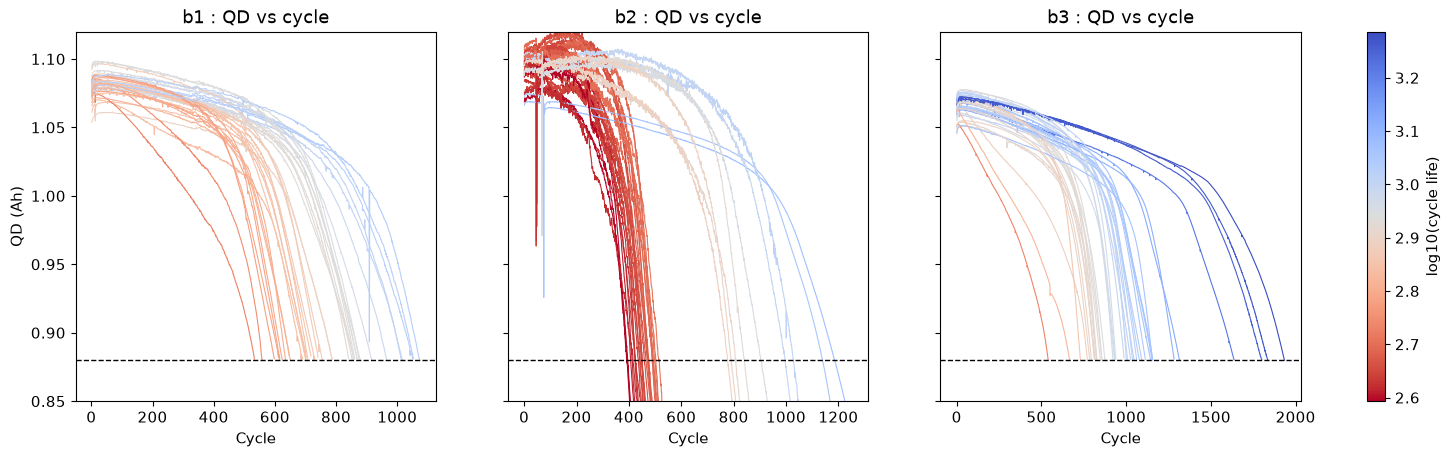

In [9]:
norm = plt.Normalize(meta['log_life'].min(), meta['log_life'].max())
cmap = cm.coolwarm_r   # 파랑 = 장수명, 빨강 = 단수명
life_of = meta.set_index('cell_id')['log_life']

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for i, b in enumerate(BATCH_FILES):
    for cid, g in summ[summ['batch'] == b].groupby('cell_id'):
        ax[i].plot(g['cycle'], g['QD'], color=cmap(norm(life_of[cid])), lw=0.8)
    ax[i].axhline(EOL_AH, color='k', ls='--', lw=1)
    ax[i].set(title=f'{b} : QD vs cycle', xlabel='Cycle', ylim=(0.85, 1.12))
ax[0].set_ylabel('QD (Ah)')
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
cb = fig.colorbar(sm, ax=ax, fraction=0.02); cb.set_label('log10(cycle life)')
plt.show()

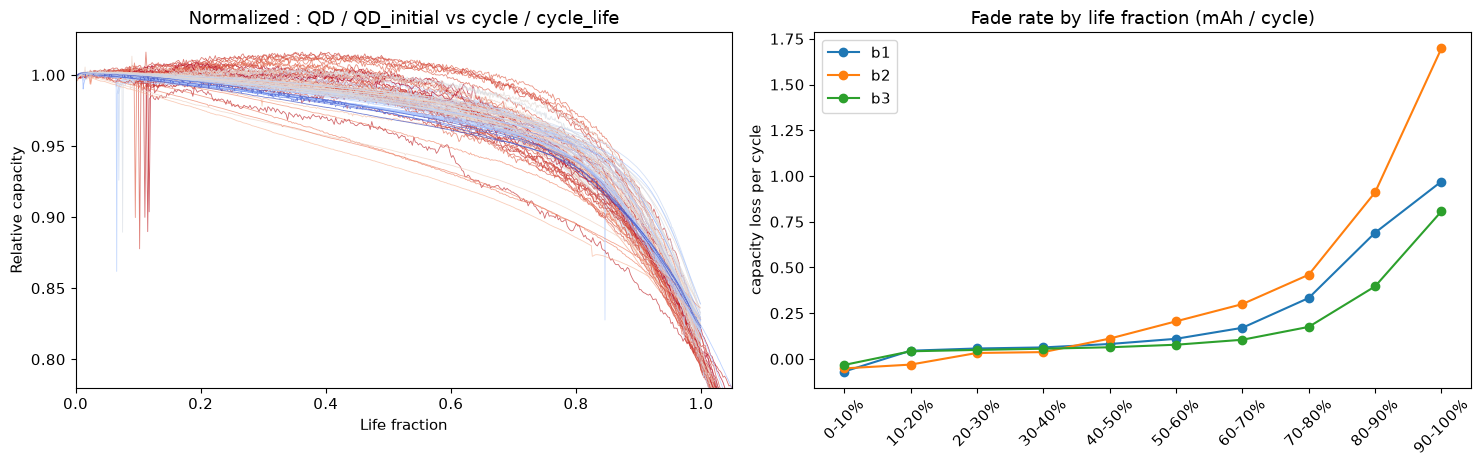

In [10]:
# 시각 바꾸기 : 사이클을 '수명 대비 진행률'로 정규화하면 모든 셀이 같은 모양인가?
fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))
for cid, g in summ.groupby('cell_id'):
    g = g[g['cycle'] >= 2]
    ref = g['QD'].iloc[:10].median()
    ax[0].plot(g['cycle'] / g['cycle_life'].iloc[0], g['QD'] / ref,
               color=cmap(norm(life_of[cid])), lw=0.6, alpha=0.7)
ax[0].set(title='Normalized : QD / QD_initial vs cycle / cycle_life',
          xlabel='Life fraction', ylabel='Relative capacity', xlim=(0, 1.05), ylim=(0.78, 1.03))

# 열화 속도 : 수명 진행률 구간별 평균 감소율 -> 가속 여부
summ['frac'] = summ['cycle'] / summ['cycle_life']
summ['frac_bin'] = pd.cut(summ['frac'], np.linspace(0, 1, 11))
rate = (summ.sort_values(['cell_id', 'cycle'])
            .assign(dQD=lambda d: d.groupby('cell_id')['QD'].transform(lambda s: s.diff().rolling(5, min_periods=1).mean()))
            .groupby(['batch', 'frac_bin'])['dQD'].mean().unstack(0) * -1000)
for b in rate.columns:
    ax[1].plot(range(len(rate)), rate[b], marker='o', color=BATCH_COLORS[b], label=b)
ax[1].set_xticks(range(len(rate))); ax[1].set_xticklabels([f'{i*10}-{i*10+10}%' for i in range(10)], rotation=45)
ax[1].set(title='Fade rate by life fraction (mAh / cycle)', ylabel='capacity loss per cycle'); ax[1].legend()
plt.tight_layout(); plt.show()

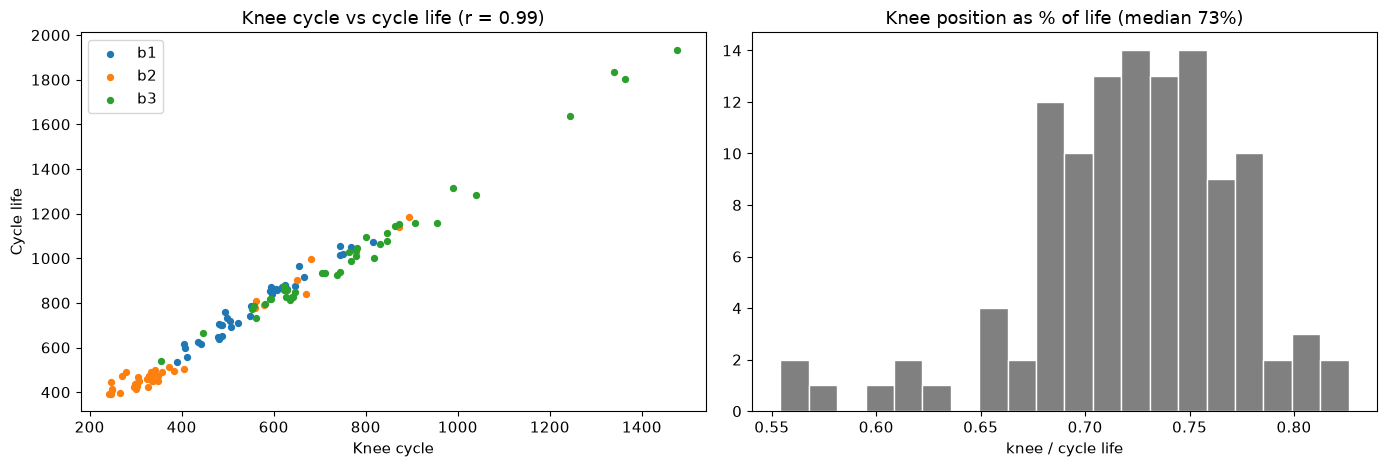

,knee,knee_frac
batch,,
b1,550.0,0.71
b2,333.0,0.70
b3,753.5,0.76


In [11]:
# Knee point : 사이클 10 ~ EOL 구간에서 시작-끝 직선과 가장 멀리 떨어진 점 (Kneedle 방식 단순화)
def find_knee(g):
    g = g[g['cycle'] >= 10].sort_values('cycle')
    qd = g['QD'].rolling(11, center=True, min_periods=1).median().values
    cy = g['cycle'].values
    end = np.argmax(qd <= EOL_AH) if (qd <= EOL_AH).any() else len(qd) - 1
    cy, qd = cy[:end + 1], qd[:end + 1]
    if len(cy) < 20:
        return np.nan
    x = (cy - cy[0]) / (cy[-1] - cy[0]); y = (qd - qd[-1]) / (qd[0] - qd[-1] + 1e-12)
    return cy[np.argmax(y - (1 - x))]

knee = summ.groupby('cell_id').apply(find_knee).rename('knee').reset_index()
meta = meta.drop(columns='knee', errors='ignore').merge(knee, on='cell_id')
meta['knee_frac'] = meta['knee'] / meta['cycle_life']

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
for b in BATCH_FILES:
    d = meta[meta['batch'] == b]
    ax[0].scatter(d['knee'], d['cycle_life'], s=18, color=BATCH_COLORS[b], label=b)
r = meta[['knee', 'cycle_life']].corr().iloc[0, 1]
ax[0].set(title=f'Knee cycle vs cycle life (r = {r:.2f})', xlabel='Knee cycle', ylabel='Cycle life'); ax[0].legend()
ax[1].hist(meta['knee_frac'].dropna(), bins=20, color='gray', edgecolor='white')
ax[1].set(title=f"Knee position as % of life (median {meta['knee_frac'].median()*100:.0f}%)", xlabel='knee / cycle life')
plt.tight_layout(); plt.show()
meta.groupby('batch')[['knee', 'knee_frac']].median().round(2)

**[작성] Q2**
- ISSUE (무엇이 궁금했나) :
- 확인 결과 (그래프 + 수치) :
- 배치 비교 :
- 핵심 발견 (한 줄) :
- 모델링 시사점 :

- 힌트 : 초기 100 사이클 구간에서 파랑/빨강 곡선이 겹치는가? → 초기 QD만으로 구분 불가 → Q3 필요성
- 힌트 : knee가 수명의 일정 비율에서 나타난다면 "수명 예측 ≈ knee 시점 예측"

## Q3. ΔQ(V) 곡선 - 초기 사이클에서 차이가 보이는가?

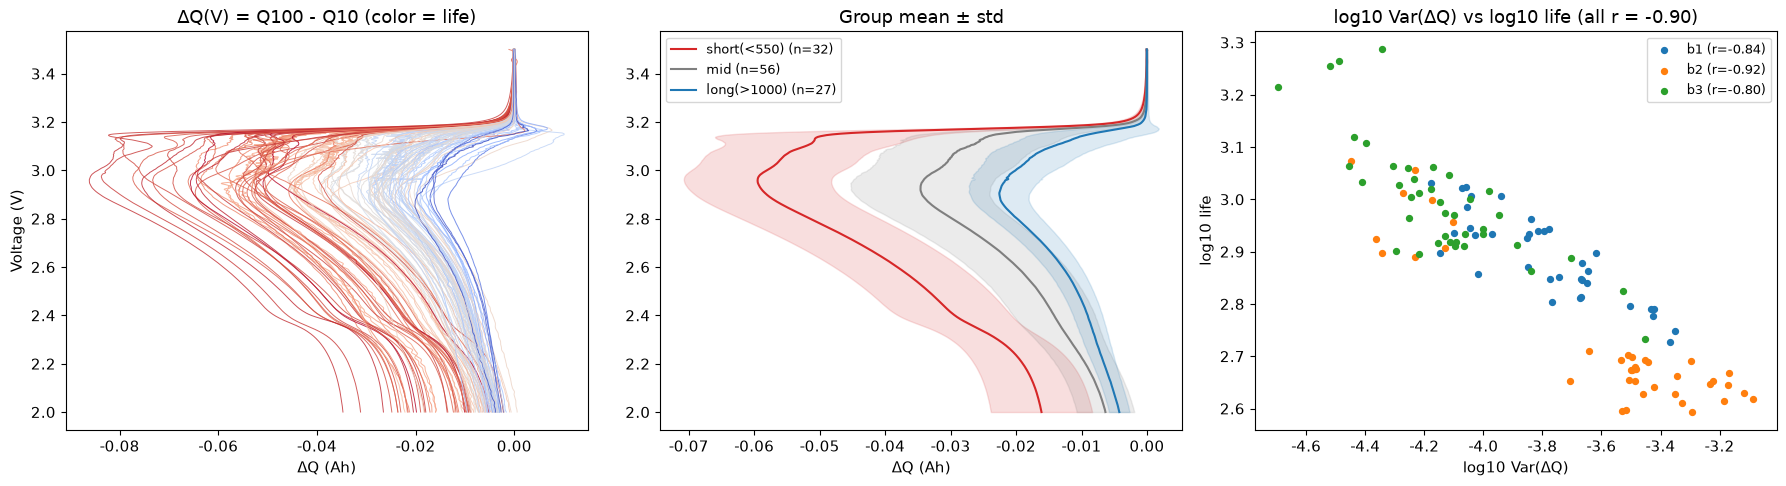

In [12]:
V = cells[0]['Vdlin']
def dq(c, a=100, b=10):
    return c['curves'][a]['Qdlin'] - c['curves'][b]['Qdlin']

DQ = {c['cell_id']: dq(c) for c in cells}
meta['group'] = pd.cut(meta['cycle_life'], [0, LABEL_TH, LONG_TH, 1e5],
                       labels=['short(<550)', 'mid', 'long(>1000)'])

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for cid, d in DQ.items():
    ax[0].plot(d, V, color=cmap(norm(life_of[cid])), lw=0.7, alpha=0.8)
ax[0].set(title='ΔQ(V) = Q100 - Q10 (color = life)', xlabel='ΔQ (Ah)', ylabel='Voltage (V)')

gcol = {'short(<550)': 'tab:red', 'mid': 'tab:gray', 'long(>1000)': 'tab:blue'}
for gname, sub in meta.groupby('group'):
    if len(sub) == 0: continue
    arr = np.vstack([DQ[c] for c in sub['cell_id']])
    m, s = arr.mean(0), arr.std(0)
    ax[1].plot(m, V, color=gcol[gname], label=f'{gname} (n={len(sub)})')
    ax[1].fill_betweenx(V, m - s, m + s, color=gcol[gname], alpha=0.15)
ax[1].set(title='Group mean ± std', xlabel='ΔQ (Ah)'); ax[1].legend(fontsize=9)

meta['dq_var'] = [np.log10(np.var(DQ[c])) for c in meta['cell_id']]
for b in BATCH_FILES:
    d = meta[meta['batch'] == b]
    ax[2].scatter(d['dq_var'], d['log_life'], s=18, color=BATCH_COLORS[b],
                  label=f"{b} (r={d[['dq_var','log_life']].corr().iloc[0,1]:.2f})")
r = meta[['dq_var', 'log_life']].corr().iloc[0, 1]
ax[2].set(title=f'log10 Var(ΔQ) vs log10 life (all r = {r:.2f})', xlabel='log10 Var(ΔQ)', ylabel='log10 life')
ax[2].legend(fontsize=9)
plt.tight_layout(); plt.show()

In [13]:
# 통계 피처 추출 : 어떤 요약값이 장/단수명을 가장 잘 구분하는가
meta['dq_min']  = [np.log10(abs(DQ[c].min()) + 1e-9) for c in meta['cell_id']]
meta['dq_mean'] = [np.log10(abs(DQ[c].mean()) + 1e-9) for c in meta['cell_id']]
meta['dq_skew'] = [stats.skew(DQ[c]) for c in meta['cell_id']]
meta['dq_kurt'] = [stats.kurtosis(DQ[c]) for c in meta['cell_id']]
DQ_FEATS = ['dq_var', 'dq_min', 'dq_mean', 'dq_skew', 'dq_kurt']

tbl = pd.DataFrame({
    'pearson(log life)' : meta[DQ_FEATS].corrwith(meta['log_life']),
    'spearman(log life)': meta[DQ_FEATS].corrwith(meta['log_life'], method='spearman'),
    **{f'pearson {b}': meta[meta['batch'] == b][DQ_FEATS].corrwith(meta[meta['batch'] == b]['log_life'])
       for b in BATCH_FILES}})
tbl.round(3)

,pearson(log life),spearman(log life),pearson b1,pearson b2,pearson b3
dq_var,-0.902,-0.879,-0.844,-0.918,-0.805
dq_min,-0.894,-0.867,-0.821,-0.901,-0.811
dq_mean,-0.870,-0.850,-0.771,-0.874,-0.760
dq_skew,-0.387,-0.405,-0.434,-0.126,-0.291
dq_kurt,0.301,0.349,0.022,0.653,0.092


**[작성] Q3**
- ISSUE (무엇이 궁금했나) :
- 확인 결과 (그래프 + 수치) :
- 배치 비교 :
- 핵심 발견 (한 줄) :
- 모델링 시사점 :

- 힌트 : 배치별 r이 비슷한가? 다르면 Batch1 학습 → Batch2 평가 시 위험 요소

## Extra. 몇 사이클이면 충분한가?

ΔQ 기준 사이클을 바꿔가며 수명과의 상관이 언제부터 강해지는지 확인 → 예측 시점과 정확도의 트레이드오프

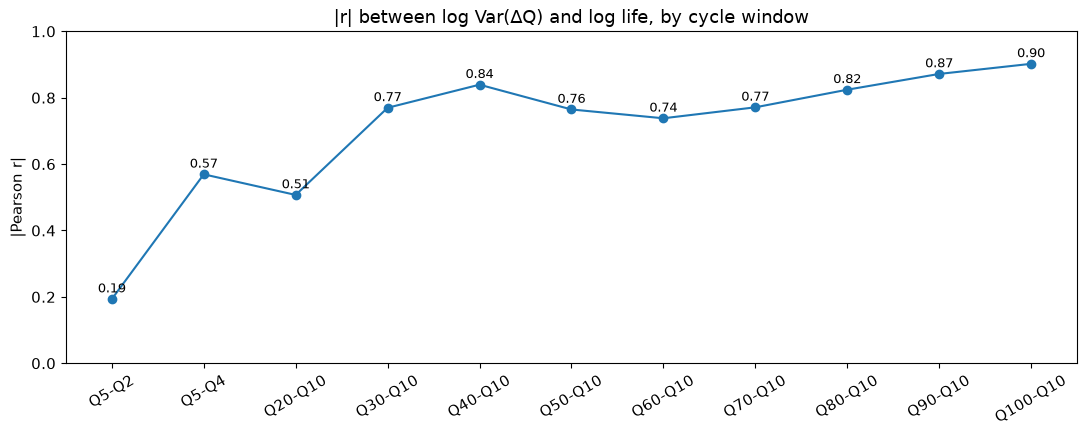

,pair,a,r,n
0,Q5-Q2,5,-0.193427,115
1,Q5-Q4,5,-0.569242,115
2,Q20-Q10,20,-0.507115,115
3,Q30-Q10,30,-0.769656,115
4,Q40-Q10,40,-0.839269,115
5,Q50-Q10,50,-0.764593,115
6,Q60-Q10,60,-0.738071,115
7,Q70-Q10,70,-0.771073,115
8,Q80-Q10,80,-0.824125,115
9,Q90-Q10,90,-0.871629,115


In [14]:
life_lookup = meta.set_index('cell_id')['cycle_life']
pairs = [(5, 2), (5, 4), (20, 10), (30, 10), (40, 10), (50, 10), (60, 10), (70, 10), (80, 10), (90, 10), (100, 10)]
res = []
for a, b in pairs:
    ok = [c for c in cells if a in c['curves'] and b in c['curves']]
    v = np.array([np.log10(np.var(dq(c, a, b)) + 1e-15) for c in ok])
    y = np.log10(life_lookup.loc[[c['cell_id'] for c in ok]].values)
    res.append({'pair': f'Q{a}-Q{b}', 'a': a, 'r': np.corrcoef(v, y)[0, 1], 'n': len(ok)})
res = pd.DataFrame(res)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(res['pair'], res['r'].abs(), marker='o')
ax.set(title='|r| between log Var(ΔQ) and log life, by cycle window', ylabel='|Pearson r|', ylim=(0, 1))
for x, yv in zip(res['pair'], res['r'].abs()):
    ax.text(x, yv + 0.02, f'{yv:.2f}', ha='center', fontsize=9)
plt.xticks(rotation=30); plt.tight_layout(); plt.show()
res

**[작성] Extra - 사이클 수**
- ISSUE (무엇이 궁금했나) :
- 확인 결과 (그래프 + 수치) :
- 배치 비교 :
- 핵심 발견 (한 줄) :
- 모델링 시사점 :

- 힌트 : 5사이클 신호가 약하면 Classification(5 cycles)의 어려움, 100사이클이 강하면 Regression 선택 근거

## Q4. 충전 조건 (C-rate)과 수명의 관계는?

In [15]:
# 정책 문자열 분해 : "C1(Q1%)-C2"  -> 0~Q1% 는 C1, Q1~80% 는 C2 로 충전
pat = re.compile(r'([\d.]+)C\((\d+)%\)-([\d.]+)C')
def parse_policy(p):
    m = pat.search(p)
    if not m:
        return pd.Series({'C1': np.nan, 'SOC1': np.nan, 'C2': np.nan, 'avgC': np.nan})
    c1, q1, c2 = float(m.group(1)), float(m.group(2)) / 100, float(m.group(3))
    t = q1 / c1 + max(0.8 - q1, 0) / c2            # 0~80% 충전 시간 (h)
    return pd.Series({'C1': c1, 'SOC1': q1 * 100, 'C2': c2, 'avgC': 0.8 / t})

meta = meta.drop(columns=['C1', 'SOC1', 'C2', 'avgC'], errors='ignore')
meta = pd.concat([meta, meta['policy'].apply(parse_policy)], axis=1)
print(f"파싱 실패 정책 : {meta['avgC'].isna().sum()} 개", meta.loc[meta['avgC'].isna(), 'policy'].unique()[:10])

# 열화 속도 : cycle 10~100 QD 선형 기울기
def slope(g):
    g = g[g['cycle'].between(10, 100)]
    return np.polyfit(g['cycle'], g['QD'], 1)[0] * 1000 if len(g) > 10 else np.nan
meta = meta.drop(columns='fade_10_100', errors='ignore').merge(
    summ.groupby('cell_id').apply(slope).rename('fade_10_100').reset_index(), on='cell_id')
meta = meta.drop(columns='Tavg_100', errors='ignore').merge(
    summ[summ['cycle'].between(2, 100)].groupby('cell_id')['Tavg'].mean().rename('Tavg_100').reset_index(), on='cell_id')

파싱 실패 정책 : 0 개 <ArrowStringArray>
[]
Length: 0, dtype: str


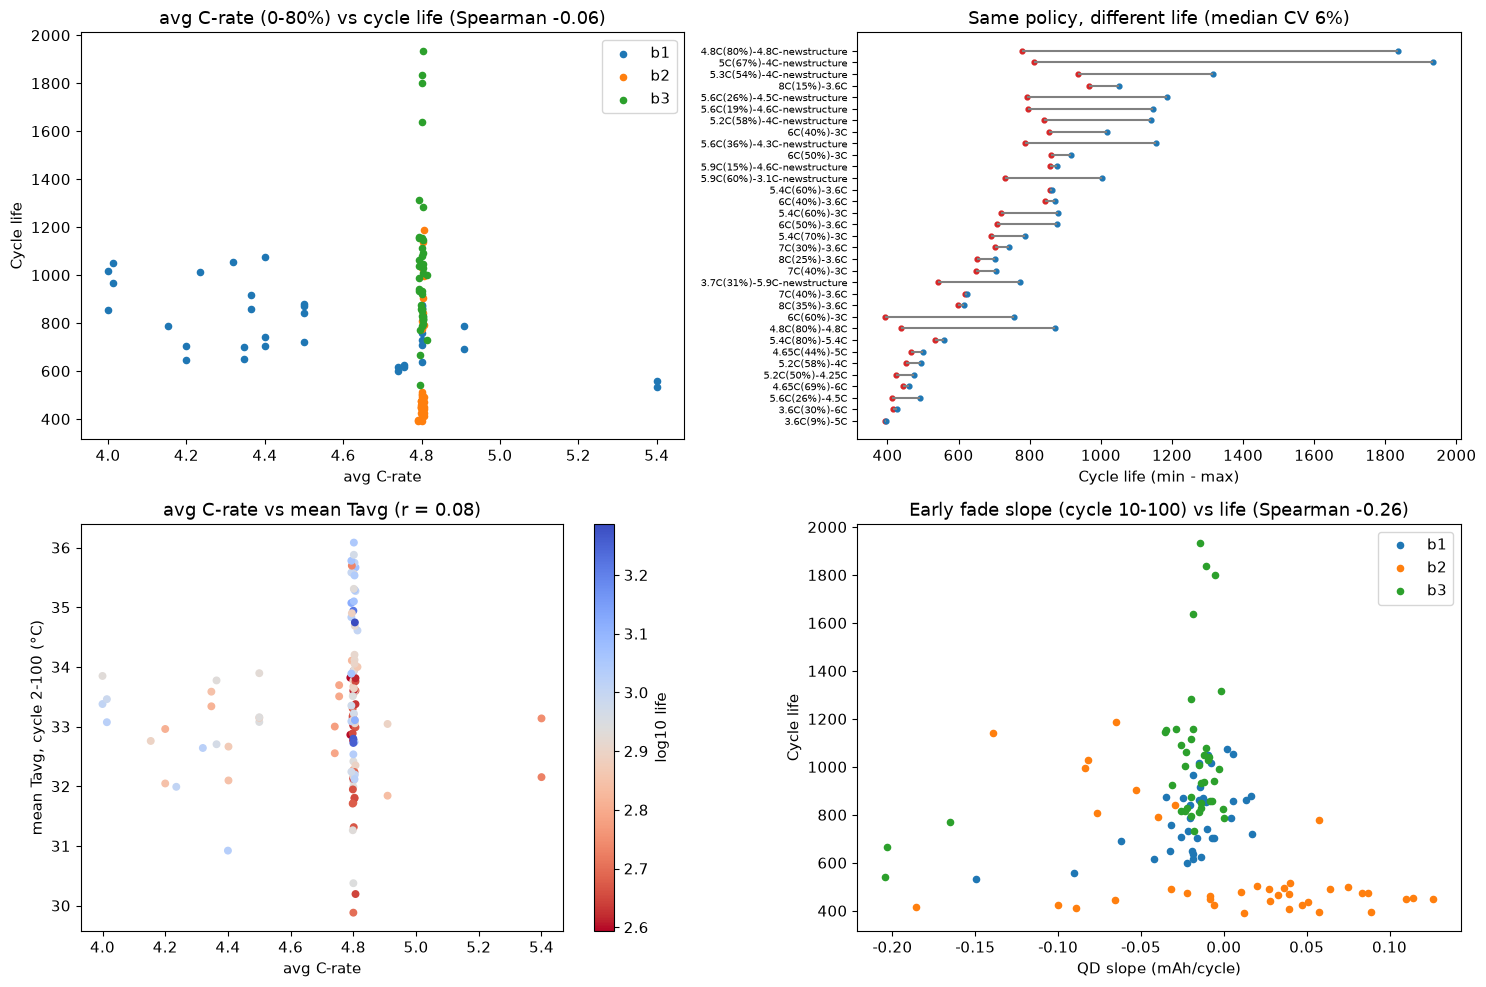

,spearman vs life,spearman vs avgC
C1,0.119,NaN
C2,-0.167,NaN
SOC1,0.055,NaN
Tavg_100,0.300,0.122
avgC,-0.057,NaN
fade_10_100,-0.261,-0.208


In [16]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# (a) 평균 C-rate vs 수명
for b in BATCH_FILES:
    d = meta[meta['batch'] == b]
    ax[0, 0].scatter(d['avgC'], d['cycle_life'], s=20, color=BATCH_COLORS[b], label=b)
rho = stats.spearmanr(meta['avgC'], meta['cycle_life'], nan_policy='omit')[0]
ax[0, 0].set(title=f'avg C-rate (0-80%) vs cycle life (Spearman {rho:.2f})', xlabel='avg C-rate', ylabel='Cycle life')
ax[0, 0].legend()

# (b) 같은 정책인데 수명이 얼마나 다른가
multi = meta.groupby('policy').filter(lambda g: len(g) >= 2)
agg = multi.groupby('policy')['cycle_life'].agg(['min', 'max', 'mean', 'count']).sort_values('mean')
ax[0, 1].hlines(range(len(agg)), agg['min'], agg['max'], color='gray')
ax[0, 1].scatter(agg['min'], range(len(agg)), color='tab:red', s=12)
ax[0, 1].scatter(agg['max'], range(len(agg)), color='tab:blue', s=12)
ax[0, 1].set_yticks(range(len(agg))); ax[0, 1].set_yticklabels(agg.index, fontsize=7)
cv = (multi.groupby('policy')['cycle_life'].std() / multi.groupby('policy')['cycle_life'].mean()).median()
ax[0, 1].set(title=f'Same policy, different life (median CV {cv*100:.0f}%)', xlabel='Cycle life (min - max)')

# (c) C-rate -> 온도 -> 수명 연결
sc = ax[1, 0].scatter(meta['avgC'], meta['Tavg_100'], c=meta['log_life'], cmap='coolwarm_r', s=22)
fig.colorbar(sc, ax=ax[1, 0], label='log10 life')
r1 = meta[['avgC', 'Tavg_100']].corr().iloc[0, 1]
ax[1, 0].set(title=f'avg C-rate vs mean Tavg (r = {r1:.2f})', xlabel='avg C-rate', ylabel='mean Tavg, cycle 2-100 (°C)')

# (d) 열화 속도 vs 수명
for b in BATCH_FILES:
    d = meta[meta['batch'] == b]
    ax[1, 1].scatter(d['fade_10_100'], d['cycle_life'], s=20, color=BATCH_COLORS[b], label=b)
rho2 = stats.spearmanr(meta['fade_10_100'], meta['cycle_life'], nan_policy='omit')[0]
ax[1, 1].set(title=f'Early fade slope (cycle 10-100) vs life (Spearman {rho2:.2f})',
             xlabel='QD slope (mAh/cycle)', ylabel='Cycle life'); ax[1, 1].legend()
plt.tight_layout(); plt.show()

pd.DataFrame({
    'spearman vs life': meta[['C1', 'SOC1', 'C2', 'avgC', 'Tavg_100', 'fade_10_100']].corrwith(meta['cycle_life'], method='spearman'),
    'spearman vs avgC': meta[['Tavg_100', 'fade_10_100']].corrwith(meta['avgC'], method='spearman'),
}).round(3)

**[작성] Q4**
- ISSUE (무엇이 궁금했나) :
- 확인 결과 (그래프 + 수치) :
- 배치 비교 :
- 핵심 발견 (한 줄) :
- 모델링 시사점 :

- 힌트 : "고속 충전 = 단수명"은 뻔한 내용 → 같은 정책 내 편차(CV), 온도 매개 여부가 '뻔하지 않은' 발견
- 힌트 : 배치별로 정책 범위가 다르면 Batch2 평가 시 학습에 없던 조건이 나올 수 있음

## Q5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

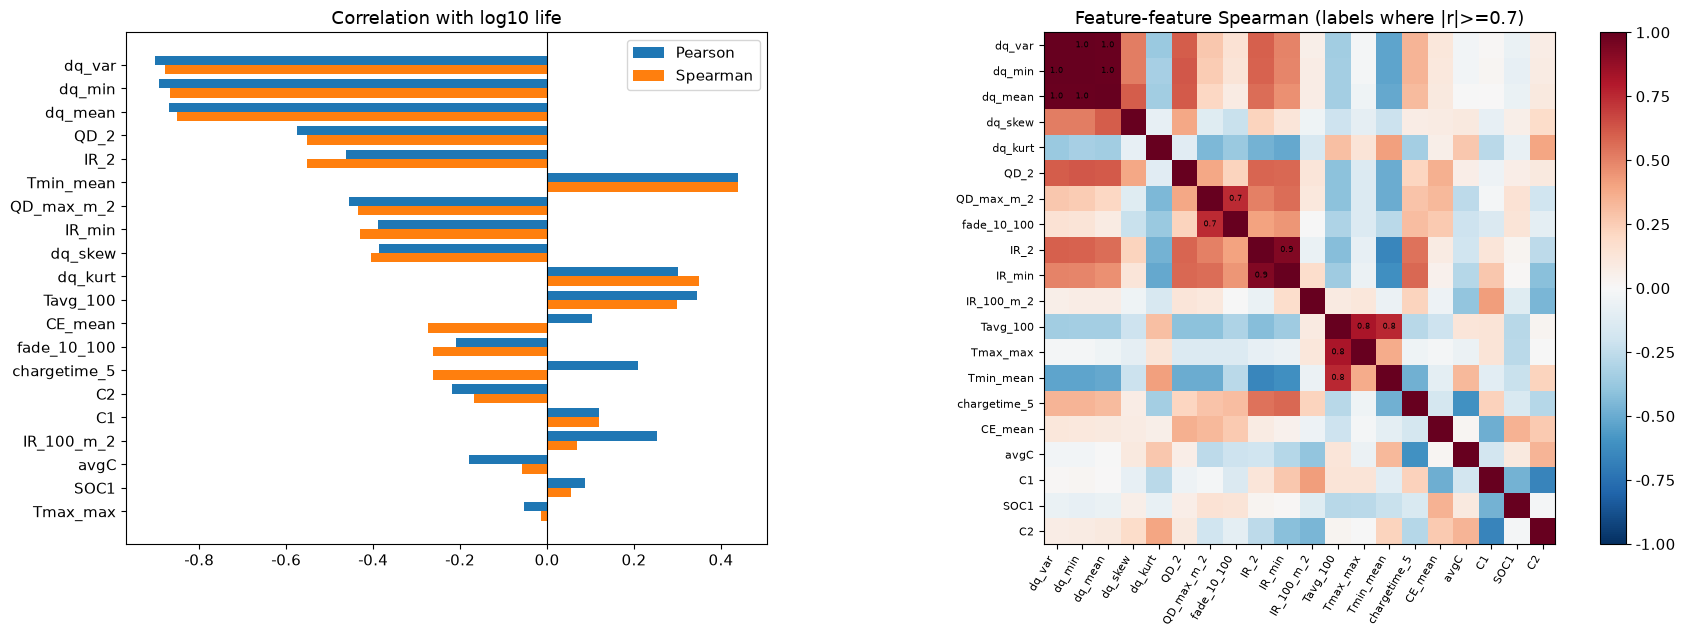

,pearson,spearman
dq_var,-0.902,-0.879
dq_min,-0.894,-0.867
dq_mean,-0.870,-0.850
QD_2,-0.576,-0.552
IR_2,-0.463,-0.551
Tmin_mean,0.439,0.439
QD_max_m_2,-0.455,-0.436
IR_min,-0.390,-0.430
dq_skew,-0.387,-0.405
dq_kurt,0.301,0.349


In [17]:
e = summ[summ['cycle'].between(2, 100)].sort_values(['cell_id', 'cycle'])
first = e.groupby('cell_id').head(1).set_index('cell_id')
fe = pd.DataFrame({
    'QD_2'        : first['QD'],
    'QD_max_m_2'  : e.groupby('cell_id')['QD'].max() - first['QD'],
    'IR_2'        : first['IR'],
    'IR_min'      : e.groupby('cell_id')['IR'].min(),
    'IR_100_m_2'  : e.groupby('cell_id')['IR'].last() - first['IR'],
    'Tmax_max'    : e.groupby('cell_id')['Tmax'].max(),
    'Tmin_mean'   : e.groupby('cell_id')['Tmin'].mean(),
    'chargetime_5': e.groupby('cell_id')['chargetime'].apply(lambda s: s.iloc[:5].mean()),
    'CE_mean'     : (e['QD'] / e['QC']).groupby(e['cell_id']).mean(),
}).reset_index()
feat = meta.merge(fe, on='cell_id')

FEATS = ['dq_var', 'dq_min', 'dq_mean', 'dq_skew', 'dq_kurt',
         'QD_2', 'QD_max_m_2', 'fade_10_100',
         'IR_2', 'IR_min', 'IR_100_m_2',
         'Tavg_100', 'Tmax_max', 'Tmin_mean', 'chargetime_5', 'CE_mean',
         'avgC', 'C1', 'SOC1', 'C2']

rank = pd.DataFrame({
    'pearson' : feat[FEATS].corrwith(feat['log_life']),
    'spearman': feat[FEATS].corrwith(feat['log_life'], method='spearman')})
rank = rank.reindex(rank['spearman'].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(1, 2, figsize=(17, 6.5), gridspec_kw={'width_ratios': [1, 1.4]})
y = np.arange(len(rank))
ax[0].barh(y - 0.2, rank['pearson'], 0.4, label='Pearson')
ax[0].barh(y + 0.2, rank['spearman'], 0.4, label='Spearman')
ax[0].set_yticks(y); ax[0].set_yticklabels(rank.index); ax[0].invert_yaxis()
ax[0].axvline(0, color='k', lw=0.8); ax[0].set(title='Correlation with log10 life'); ax[0].legend()

cm_ = feat[FEATS].corr(method='spearman')
im = ax[1].imshow(cm_, cmap='RdBu_r', vmin=-1, vmax=1)
ax[1].set_xticks(range(len(FEATS))); ax[1].set_xticklabels(FEATS, rotation=60, ha='right', fontsize=8)
ax[1].set_yticks(range(len(FEATS))); ax[1].set_yticklabels(FEATS, fontsize=8)
for i in range(len(FEATS)):
    for j in range(len(FEATS)):
        if i != j and abs(cm_.iloc[i, j]) >= 0.7:
            ax[1].text(j, i, f'{cm_.iloc[i, j]:.1f}', ha='center', va='center', fontsize=6)
fig.colorbar(im, ax=ax[1], fraction=0.03); ax[1].set_title('Feature-feature Spearman (labels where |r|>=0.7)')
plt.tight_layout(); plt.show()
rank.round(3)

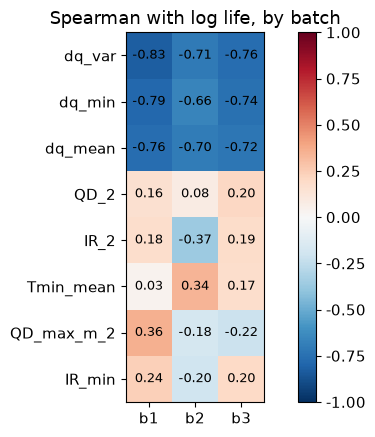

VIF (>10 이면 다중공선성 심각) :


dq_min        358.0
dq_var        336.6
dq_mean        68.6
IR_min          6.2
IR_2            6.0
QD_2            2.6
Tmin_mean       1.8
QD_max_m_2      1.8
dtype: float64

In [18]:
# 시각 바꾸기 : 상위 피처의 상관이 배치마다 일관적인가? (일반화 관점)
top = rank.index[:8]
by_batch = pd.DataFrame({b: feat[feat['batch'] == b][top].corrwith(feat[feat['batch'] == b]['log_life'], method='spearman')
                         for b in BATCH_FILES})
fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(by_batch, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(BATCH_FILES))); ax.set_xticklabels(list(BATCH_FILES))
ax.set_yticks(range(len(top))); ax.set_yticklabels(top)
for i in range(len(top)):
    for j in range(len(BATCH_FILES)):
        ax.text(j, i, f'{by_batch.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax); ax.set_title('Spearman with log life, by batch')
plt.tight_layout(); plt.show()

# 다중공선성 : VIF (상위 피처 기준)
def vif(X):
    X = (X - X.mean()) / X.std()
    out = {}
    for c in X.columns:
        A = np.c_[np.ones(len(X)), X.drop(columns=c).values]
        beta, *_ = np.linalg.lstsq(A, X[c].values, rcond=None)
        resid = X[c].values - A @ beta
        r2 = 1 - (resid ** 2).sum() / ((X[c] - X[c].mean()) ** 2).sum()
        out[c] = 1 / (1 - r2) if r2 < 1 else np.inf
    return pd.Series(out).sort_values(ascending=False)

print('VIF (>10 이면 다중공선성 심각) :')
vif(feat[list(top)].dropna()).round(1)

**[작성] Q5**
- ISSUE (무엇이 궁금했나) :
- 확인 결과 (그래프 + 수치) :
- 배치 비교 :
- 핵심 발견 (한 줄) :
- 모델링 시사점 :

- 힌트 : Pearson과 Spearman 차이가 크면 비선형/이상치 영향 → 모델 선택 근거
- 힌트 : VIF 높은 묶음(예: 온도 계열, ΔQ 계열)은 하나만 쓰거나 규제 모델로 처리

In [19]:
# Day2 용 피처 저장
feat.to_csv('features_day1.csv', index=False)
print(feat.shape, '-> features_day1.csv')

(115, 30) -> features_day1.csv


## 모델 설계 전략 (EDA 결과 보고 수정)

**1. Feature Engineering**
- 채택 : (Q3/Q5에서 상관 높고 배치 간 일관된 피처) / 근거 :
- 제외 : (VIF 높거나 상관 약한 피처) / 근거 :
- 누수 방지 : 모든 피처는 cycle 100 이전 데이터만 사용

**2. Regression vs Classification → 선택 :**
- Target :
- 근거 1 (Q1) : Batch1 기준 550 미만 셀 수 → 분류 학습 가능성
- 근거 2 (Q3, Extra) : ΔQ 신호가 몇 사이클부터 강해지는가
- 근거 3 (Domain) : 교체 계획(CAPEX 30~40%) 관점에서 필요한 출력 형태

**3. Modeling Strategy**
- 데이터 처리 : 정제 규칙, log 변환(Q1), 스케일링
- 분할 : 학습 Batch1 / 평가 Batch2 (+3), 배치 간 분포 차이(Q1, Q3, Q5 배치 비교)에서 오는 위험
- 후보 모델과 차별점 :
  - 규제 선형(ElasticNet) : 
  - 트리 앙상블(RF / GBM) : 
  - (선택 안 한 이유) 딥러닝 : 
- 검증 : Batch1 내부 CV 방식, 목표 성능(논문 기준)과 비교 계획